# Tratamento dos dados - LUSC

In [ ]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from statsmodels.stats.multitest import multipletests

In [2]:
COHORT = "LUSC"

PROJECT_DIR = Path("..").resolve()

RAW_DIR = PROJECT_DIR / "data" / "raw" / "lusc"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed" / "lusc"
FIGURES_DIR = PROJECT_DIR / "reports" / "figures" / "lusc"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "surv": RAW_DIR / "survival_lusc.txt",
    "clin": RAW_DIR / "TCGA.LUSC.sampleMap_LUSC_clinicalMatrix",
    "expr": RAW_DIR / "HiSeqV2_lusc",
}

TIME_COL = "surv__OS.time"
EVENT_COL = "surv__OS"

SEED = 42

In [3]:
def criar_patient_id(sample):
    """
    Cria o patient_id no padrão TCGA-XX-XXXX.
    """
    if pd.isna(sample):
        return np.nan
    return str(sample)[:12]


def pegar_sample_code(sample):
    """
    Pega o código da amostra TCGA.
    Exemplo:
    TCGA-18-3406-01 -> 01
    TCGA-18-3406-11 -> 11
    """
    if pd.isna(sample):
        return ""

    sample = str(sample)
    partes = sample.split("-")

    if len(partes) >= 4:
        return partes[3][:2]

    achou = re.search(r"-(\d{2})[A-Z]?", sample)
    if achou:
        return achou.group(1)

    return ""


def mostrar_resumo(df, nome):
    """
    Mostra um resumo simples da base.
    """
    print(f"\n{nome}")
    print("-" * 60)
    print("Shape:", df.shape)
    print("Total de nulos:", int(df.isna().sum().sum()))
    display(df.head())

## 1. Tratamento da base de sobrevida

Nesta etapa, vou tratar as colunas de sobrevida:

- `OS`: indica se ocorreu o evento.
- `OS.time`: tempo até o evento ou censura.

Também vou manter apenas amostras tumorais primárias, identificadas pelo código `01`.

In [4]:
print("LUSC - SURVIVAL")
print()

lusc_surv = (
    pd.read_csv(FILES["surv"], sep="\t", index_col=0)
    .reset_index()
    .rename(columns={"index": "sample_id"})
)

print("Tamanho:", lusc_surv.shape)
print("Colunas:", lusc_surv.columns.tolist())

display(lusc_surv.head())

LUSC - SURVIVAL

Tamanho: (504, 11)
Colunas: ['xena_sample', '_PATIENT', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time', 'Redaction']


,xena_sample,_PATIENT,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,Redaction
0,TCGA-18-3406-01,TCGA-18-3406,1,371.0,1.0,371.0,NaN,NaN,1,357.0,NaN
1,TCGA-18-3407-01,TCGA-18-3407,1,136.0,0.0,136.0,NaN,NaN,0,136.0,NaN
2,TCGA-18-3408-01,TCGA-18-3408,1,2304.0,1.0,2304.0,NaN,NaN,1,1793.0,NaN
3,TCGA-18-3409-01,TCGA-18-3409,0,3747.0,0.0,3747.0,0.0,3747.0,1,2291.0,NaN
4,TCGA-18-3410-01,TCGA-18-3410,1,146.0,0.0,146.0,NaN,NaN,0,146.0,NaN


In [5]:
if "_PATIENT" in lusc_surv.columns:
    lusc_surv["patient_id"] = lusc_surv["_PATIENT"].astype(str)
else:
    lusc_surv["patient_id"] = lusc_surv["xena_sample"].apply(criar_patient_id)

display(lusc_surv[["xena_sample", "patient_id"]].head())

,xena_sample,patient_id
0,TCGA-18-3406-01,TCGA-18-3406
1,TCGA-18-3407-01,TCGA-18-3407
2,TCGA-18-3408-01,TCGA-18-3408
3,TCGA-18-3409-01,TCGA-18-3409
4,TCGA-18-3410-01,TCGA-18-3410


In [6]:
lusc_surv["OS"] = pd.to_numeric(lusc_surv["OS"], errors="coerce")
lusc_surv["OS.time"] = pd.to_numeric(lusc_surv["OS.time"], errors="coerce")

lusc_surv["OS_months"] = lusc_surv["OS.time"] / 30.44
lusc_surv["OS_years"] = lusc_surv["OS.time"] / 365.25

display(lusc_surv[["xena_sample", "patient_id", "OS", "OS.time", "OS_months", "OS_years"]].head())

,xena_sample,patient_id,OS,OS.time,OS_months,OS_years
0,TCGA-18-3406-01,TCGA-18-3406,1,371.0,12.187911,1.015743
1,TCGA-18-3407-01,TCGA-18-3407,1,136.0,4.467806,0.372348
2,TCGA-18-3408-01,TCGA-18-3408,1,2304.0,75.689882,6.308008
3,TCGA-18-3409-01,TCGA-18-3409,0,3747.0,123.094612,10.258727
4,TCGA-18-3410-01,TCGA-18-3410,1,146.0,4.796321,0.399726


In [7]:
lusc_surv["sample_code"] = lusc_surv["xena_sample"].apply(pegar_sample_code)

print("Contagem dos códigos de amostra:")
print(lusc_surv["sample_code"].value_counts(dropna=False))

Contagem dos códigos de amostra:
sample_code
01    504
Name: count, dtype: int64


In [8]:
lusc_surv_01 = lusc_surv[lusc_surv["sample_code"] == "01"].copy()

print("Shape após filtro sample_code == 01:", lusc_surv_01.shape)

display(lusc_surv_01[["xena_sample", "patient_id", "OS", "OS.time"]].head())

Shape após filtro sample_code == 01: (504, 15)


,xena_sample,patient_id,OS,OS.time
0,TCGA-18-3406-01,TCGA-18-3406,1,371.0
1,TCGA-18-3407-01,TCGA-18-3407,1,136.0
2,TCGA-18-3408-01,TCGA-18-3408,1,2304.0
3,TCGA-18-3409-01,TCGA-18-3409,0,3747.0
4,TCGA-18-3410-01,TCGA-18-3410,1,146.0


In [9]:
antes = len(lusc_surv_01)

lusc_surv_01 = (
    lusc_surv_01
    .sort_values("xena_sample")
    .drop_duplicates(subset=["patient_id"], keep="first")
    .copy()
)

depois = len(lusc_surv_01)

print("Duplicados removidos:", antes - depois)
print("Pacientes únicos:", lusc_surv_01["patient_id"].nunique())

Duplicados removidos: 0
Pacientes únicos: 504


In [10]:
antes = len(lusc_surv_01)

lusc_surv_01 = (
    lusc_surv_01
    .sort_values("xena_sample")
    .drop_duplicates(subset=["patient_id"], keep="first")
    .copy()
)

depois = len(lusc_surv_01)

print("Duplicados removidos:", antes - depois)
print("Pacientes únicos:", lusc_surv_01["patient_id"].nunique())

Duplicados removidos: 0
Pacientes únicos: 504


In [11]:
print("Taxa de eventos OS=1:", round(lusc_surv_01["OS"].mean(skipna=True), 4))
print("OS.time min/med/max:",
      lusc_surv_01["OS.time"].min(skipna=True),
      lusc_surv_01["OS.time"].median(skipna=True),
      lusc_surv_01["OS.time"].max(skipna=True))

print("OS faltando:", lusc_surv_01["OS"].isna().sum())
print("OS.time faltando:", lusc_surv_01["OS.time"].isna().sum())
print("OS inválidos:", (~lusc_surv_01["OS"].isin([0, 1]) & lusc_surv_01["OS"].notna()).sum())
print("OS.time <= 0:", (lusc_surv_01["OS.time"].fillna(np.inf) <= 0).sum())

Taxa de eventos OS=1: 0.4345
OS.time min/med/max: 0.0 666.5 5287.0
OS faltando: 0
OS.time faltando: 6
OS inválidos: 0
OS.time <= 0: 1


In [12]:
# Criar flags para saber o que foi removido
lusc_surv_01["os_missing"] = lusc_surv_01["OS"].isna().astype(int)
lusc_surv_01["os_time_missing"] = lusc_surv_01["OS.time"].isna().astype(int)

lusc_surv_01["os_invalid"] = (
    ~lusc_surv_01["OS"].isin([0, 1]) & lusc_surv_01["OS"].notna()
).astype(int)

lusc_surv_01["os_time_leq0"] = (
    lusc_surv_01["OS.time"].fillna(np.inf) <= 0
).astype(int)

# Manter apenas tempos positivos
lusc_surv_01["OS.time_clean"] = lusc_surv_01["OS.time"].where(
    lusc_surv_01["OS.time"] > 0,
    np.nan
)

antes = len(lusc_surv_01)

lusc_surv_model = lusc_surv_01[
    lusc_surv_01["OS"].isin([0, 1])
    & lusc_surv_01["OS.time_clean"].notna()
].copy()

depois = len(lusc_surv_model)

print("Antes:", antes)
print("Depois:", depois)
print("Removidos:", antes - depois)
print("Taxa de eventos pós-filtro:", round(lusc_surv_model["OS"].mean() * 100, 2), "%")
print("OS.time_clean min/med/max:",
      lusc_surv_model["OS.time_clean"].min(),
      lusc_surv_model["OS.time_clean"].median(),
      lusc_surv_model["OS.time_clean"].max())

Antes: 504
Depois: 497
Removidos: 7
Taxa de eventos pós-filtro: 43.26 %
OS.time_clean min/med/max: 1.0 667.0 5287.0


In [13]:
lusc_surv_final = (
    lusc_surv_model[["patient_id", "OS.time_clean", "OS"]]
    .rename(columns={"OS.time_clean": "OS.time"})
    .copy()
)

lusc_surv_final = lusc_surv_final.set_index("patient_id")

mostrar_resumo(lusc_surv_final, "LUSC survival final")


LUSC survival final
------------------------------------------------------------
Shape: (497, 2)
Total de nulos: 0


,OS.time,OS
patient_id,,
TCGA-18-3406,371.0,1
TCGA-18-3407,136.0,1
TCGA-18-3408,2304.0,1
TCGA-18-3409,3747.0,0
TCGA-18-3410,146.0,1


In [14]:
lusc_surv_final = (
    lusc_surv_model[["patient_id", "OS.time_clean", "OS"]]
    .rename(columns={"OS.time_clean": "OS.time"})
    .copy()
)

lusc_surv_final = lusc_surv_final.set_index("patient_id")

mostrar_resumo(lusc_surv_final, "LUSC survival final")


LUSC survival final
------------------------------------------------------------
Shape: (497, 2)
Total de nulos: 0


,OS.time,OS
patient_id,,
TCGA-18-3406,371.0,1
TCGA-18-3407,136.0,1
TCGA-18-3408,2304.0,1
TCGA-18-3409,3747.0,0
TCGA-18-3410,146.0,1


In [17]:
lusc_surv_final.reset_index().to_csv(
    PROCESSED_DIR / "lusc_survival_clean.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print(PROCESSED_DIR / "lusc_survival_clean.csv")

/workspaces/An-lise-de-Sobrevida/data/processed/lusc/lusc_survival_clean.csv


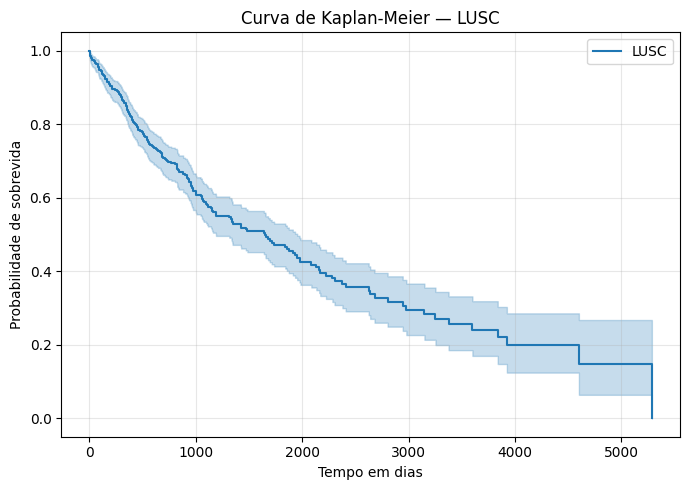

Figura salva: /workspaces/An-lise-de-Sobrevida/reports/figures/lusc/lusc_kaplan_meier.png


In [16]:
kmf = KaplanMeierFitter()

kmf.fit(
    durations=lusc_surv_final["OS.time"],
    event_observed=lusc_surv_final["OS"],
    label="LUSC"
)

fig, ax = plt.subplots(figsize=(7, 5))

kmf.plot_survival_function(ax=ax, ci_show=True)

ax.set_title("Curva de Kaplan-Meier — LUSC")
ax.set_xlabel("Tempo em dias")
ax.set_ylabel("Probabilidade de sobrevida")
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "lusc_kaplan_meier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura salva:", FIGURES_DIR / "lusc_kaplan_meier.png")

In [18]:
resumo_surv_lusc = pd.DataFrame({
    "coorte": ["LUSC"],
    "n_pacientes": [len(lusc_surv_final)],
    "n_eventos": [int(lusc_surv_final["OS"].sum())],
    "n_censurados": [int((lusc_surv_final["OS"] == 0).sum())],
    "taxa_eventos_%": [round(lusc_surv_final["OS"].mean() * 100, 2)],
    "tempo_min_dias": [lusc_surv_final["OS.time"].min()],
    "tempo_mediano_dias": [lusc_surv_final["OS.time"].median()],
    "tempo_max_dias": [lusc_surv_final["OS.time"].max()],
})

display(resumo_surv_lusc)

resumo_surv_lusc.to_csv(
    PROCESSED_DIR / "lusc_survival_summary.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

,coorte,n_pacientes,n_eventos,n_censurados,taxa_eventos_%,tempo_min_dias,tempo_mediano_dias,tempo_max_dias
0,LUSC,497,215,282,43.26,1.0,667.0,5287.0


## 2. Tratamento da base clínica

Nesta etapa, vou selecionar e tratar as variáveis clínicas de LUSC.

Variáveis principais:
- idade;
- sexo;
- tipo histológico;
- tratamento neoadjuvante;
- tabagismo;
- TNM;
- estágio patológico;
- radioterapia;
- tumor residual.

Atenção:
`vital_status` será usado apenas para auditoria, mas não deve entrar na base final de modelagem, porque está relacionado diretamente ao desfecho.

In [19]:
print("LUSC — CLINICAL")
print()

lusc_clin = (
    pd.read_csv(FILES["clin"], sep="\t", index_col=0)
    .reset_index()
    .rename(columns={"index": "sample_id"})
)

print("Tamanho:", lusc_clin.shape)
print("Primeiras colunas:", list(lusc_clin.columns[:30]))

display(lusc_clin.head())

LUSC — CLINICAL

Tamanho: (626, 118)
Primeiras colunas: ['sampleID', '_INTEGRATION', '_PANCAN_CNA_PANCAN_K8', '_PANCAN_Cluster_Cluster_PANCAN', '_PANCAN_DNAMethyl_LUSC', '_PANCAN_DNAMethyl_PANCAN', '_PANCAN_RPPA_PANCAN_K8', '_PANCAN_UNC_RNAseq_PANCAN_K16', '_PANCAN_miRNA_PANCAN', '_PANCAN_mirna_LUSC', '_PANCAN_mutation_PANCAN', '_PATIENT', '_cohort', '_primary_disease', '_primary_site', 'additional_pharmaceutical_therapy', 'additional_radiation_therapy', 'additional_surgery_locoregional_procedure', 'additional_surgery_metastatic_procedure', 'age_at_initial_pathologic_diagnosis', 'anatomic_neoplasm_subdivision', 'anatomic_neoplasm_subdivision_other', 'bcr_followup_barcode', 'bcr_patient_barcode', 'bcr_sample_barcode', 'days_to_additional_surgery_locoregional_procedure', 'days_to_additional_surgery_metastatic_procedure', 'days_to_birth', 'days_to_collection', 'days_to_death']


,sampleID,_INTEGRATION,_PANCAN_CNA_PANCAN_K8,_PANCAN_Cluster_Cluster_PANCAN,_PANCAN_DNAMethyl_LUSC,_PANCAN_DNAMethyl_PANCAN,_PANCAN_RPPA_PANCAN_K8,_PANCAN_UNC_RNAseq_PANCAN_K16,_PANCAN_miRNA_PANCAN,_PANCAN_mirna_LUSC,_PANCAN_mutation_PANCAN,_PATIENT,_cohort,_primary_disease,_primary_site,additional_pharmaceutical_therapy,additional_radiation_therapy,additional_surgery_locoregional_procedure,additional_surgery_metastatic_procedure,age_at_initial_pathologic_diagnosis,anatomic_neoplasm_subdivision,anatomic_neoplasm_subdivision_other,bcr_followup_barcode,bcr_patient_barcode,bcr_sample_barcode,days_to_additional_surgery_locoregional_procedure,days_to_additional_surgery_metastatic_procedure,days_to_birth,days_to_collection,days_to_death,days_to_initial_pathologic_diagnosis,days_to_last_followup,days_to_new_tumor_event_after_initial_treatment,dlco_predictive_percent,eastern_cancer_oncology_group,egfr_mutation_performed,egfr_mutation_result,eml4_alk_translocation_method,eml4_alk_translocation_performed,followup_case_report_form_submission_reason,followup_treatment_success,form_completion_date,gender,histological_type,history_of_neoadjuvant_treatment,icd_10,icd_o_3_histology,icd_o_3_site,informed_consent_verified,initial_weight,intermediate_dimension,is_ffpe,karnofsky_performance_score,kras_gene_analysis_performed,kras_mutation_found,kras_mutation_result,location_in_lung_parenchyma,longest_dimension,lost_follow_up,new_neoplasm_event_type,new_tumor_event_after_initial_treatment,number_pack_years_smoked,oct_embedded,other_dx,pathologic_M,pathologic_N,pathologic_T,pathologic_stage,pathology_report_file_name,patient_id,performance_status_scale_timing,person_neoplasm_cancer_status,post_bronchodilator_fev1_fvc_percent,post_bronchodilator_fev1_percent,pre_bronchodilator_fev1_fvc_percent,pre_bronchodilator_fev1_percent,primary_therapy_outcome_success,progression_determined_by,pulmonary_function_test_performed,radiation_therapy,residual_tumor,sample_type,sample_type_id,shortest_dimension,stopped_smoking_year,system_version,targeted_molecular_therapy,tissue_prospective_collection_indicator,tissue_retrospective_collection_indicator,tissue_source_site,tobacco_smoking_history,tumor_tissue_site,vial_number,vital_status,year_of_initial_pathologic_diagnosis,year_of_tobacco_smoking_onset,_GENOMIC_ID_TCGA_LUSC_mutation_broad_gene,_GENOMIC_ID_TCGA_LUSC_hMethyl27,_GENOMIC_ID_TCGA_LUSC_exp_HiSeqV2,_GENOMIC_ID_data/public/TCGA/LUSC/miRNA_HiSeq_gene,_GENOMIC_ID_TCGA_LUSC_miRNA_GA,_GENOMIC_ID_TCGA_LUSC_mutation,_GENOMIC_ID_TCGA_LUSC_PDMRNAseq,_GENOMIC_ID_TCGA_LUSC_G4502A_07_3,_GENOMIC_ID_TCGA_LUSC_miRNA_HiSeq,_GENOMIC_ID_TCGA_LUSC_exp_HiSeqV2_percentile,_GENOMIC_ID_TCGA_LUSC_exp_u133a,_GENOMIC_ID_TCGA_LUSC_RPPA_RBN,_GENOMIC_ID_TCGA_LUSC_PDMRNAseqCNV,_GENOMIC_ID_TCGA_LUSC_gistic2,_GENOMIC_ID_TCGA_LUSC_PDMarray,_GENOMIC_ID_TCGA_LUSC_exp_HiSeqV2_exon,_GENOMIC_ID_TCGA_LUSC_PDMarrayCNV,_GENOMIC_ID_TCGA_LUSC_exp_HiSeqV2_PANCAN,_GENOMIC_ID_data/public/TCGA/LUSC/miRNA_GA_gene,_GENOMIC_ID_TCGA_LUSC_gistic2thd,_GENOMIC_ID_TCGA_LUSC_hMethyl450,_GENOMIC_ID_TCGA_LUSC_RPPA
0,TCGA-18-3406-01,TCGA-18-3406-01,Squamous,C2-Squamous-like,cluster 1,Cluster 13 (HNSC-LUSC),NaN,squamous-like c4,miRNA cluster 11,cluster 1,mutation cluster 5,TCGA-18-3406,TCGA Lung Squamous Cell Carcinoma (LUSC),lung squamous cell carcinoma,Lung,NO,NO,NO,NaN,67.0,L-Upper,NaN,TCGA-18-3406-F69068,TCGA-18-3406,TCGA-18-3406-01A,NaN,NaN,-24477.0,NaN,371,0.0,NaN,357.0,NaN,NaN,NaN,NaN,NaN,NaN,Scheduled Follow-up Submission,NaN,2014-12-29,MALE,Lung Squamous Cell Carcinoma- Not Otherwise Sp...,No,C34.1,8070/3,C34.1,YES,NaN,0.5,NO,0.0,NaN,NaN,NaN,NaN,0.8,NO,Locoregional Recurrence,YES,200.0,NaN,Yes,M0,N0,T1,Stage IA,TCGA-18-3406.a0eef850-7543-4f82-8e46-3d81e2034...,3406,NaN,WITH TUMOR,NaN,NaN,NaN,NaN,Progressive Disease,Convincing Imaging,NaN,NO,R0,Primary Tumor,1,0.3,NaN,NaN,NO,NO,YES,18,4,Lung,A,DECEASED,2003.0,1951.0,TCGA-18-3406-01A-01D-0983-08,TCGA-18-3406-01A-01D-0979-05,99516b1e-9ee2-48d9-90e4-e78370eccef

In [20]:
# Criar patient_id
if "sampleID" in lusc_clin.columns:
    lusc_clin["patient_id"] = lusc_clin["sampleID"].apply(criar_patient_id)
else:
    lusc_clin["patient_id"] = lusc_clin["sample_id"].apply(criar_patient_id)

# Criar sample_code
if "sampleID" in lusc_clin.columns:
    lusc_clin["sample_code"] = lusc_clin["sampleID"].apply(pegar_sample_code)
else:
    lusc_clin["sample_code"] = lusc_clin["sample_id"].apply(pegar_sample_code)

display(lusc_clin[["sampleID", "patient_id", "sample_code"]].head())
print(lusc_clin["sample_code"].value_counts(dropna=False).head())

,sampleID,patient_id,sample_code
0,TCGA-18-3406-01,TCGA-18-3406,01
1,TCGA-18-3406-11,TCGA-18-3406,11
2,TCGA-18-3407-01,TCGA-18-3407,01
3,TCGA-18-3407-11,TCGA-18-3407,11
4,TCGA-18-3408-01,TCGA-18-3408,01


sample_code
01    506
11    120
Name: count, dtype: int64


In [21]:
# Filtrar apenas amostras tumorais primárias
lusc_clin_01 = lusc_clin[lusc_clin["sample_code"] == "01"].copy()

print("Depois do filtro sample_code == 01:", lusc_clin_01.shape)
print("Pacientes únicos:", lusc_clin_01["patient_id"].nunique())

Depois do filtro sample_code == 01: (506, 119)
Pacientes únicos: 506


In [22]:
antes = len(lusc_clin_01)

lusc_clin_01 = (
    lusc_clin_01
    .sort_values("sampleID")
    .drop_duplicates(subset=["patient_id"], keep="first")
    .copy()
)

depois = len(lusc_clin_01)

print("Duplicatas removidas:", antes - depois)
print("Shape final após deduplicação:", lusc_clin_01.shape)
print("Pacientes únicos:", lusc_clin_01["patient_id"].nunique())

Duplicatas removidas: 0
Shape final após deduplicação: (506, 119)
Pacientes únicos: 506


In [23]:
# Seleção das colunas clínicas que serão analisadas
cols_wanted = [
    "sampleID",
    "_INTEGRATION",
    "_PATIENT",
    "patient_id",

    "age_at_initial_pathologic_diagnosis",
    "anatomic_neoplasm_subdivision",
    "gender",
    "histological_type",
    "history_of_neoadjuvant_treatment",

    "number_pack_years_smoked",
    "tobacco_smoking_history",

    "pathologic_M",
    "pathologic_N",
    "pathologic_T",
    "pathologic_stage",

    "radiation_therapy",
    "residual_tumor",
    "vital_status",
]

missing = [c for c in cols_wanted if c not in lusc_clin_01.columns]
present = [c for c in cols_wanted if c in lusc_clin_01.columns]

lusc_clin_sel = lusc_clin_01[present].copy()

print("[lusc_clin_sel] shape:", lusc_clin_sel.shape)
print("Colunas ausentes:", missing)

display(lusc_clin_sel.head())

[lusc_clin_sel] shape: (506, 18)
Colunas ausentes: []


,sampleID,_INTEGRATION,_PATIENT,patient_id,age_at_initial_pathologic_diagnosis,anatomic_neoplasm_subdivision,gender,histological_type,history_of_neoadjuvant_treatment,number_pack_years_smoked,tobacco_smoking_history,pathologic_M,pathologic_N,pathologic_T,pathologic_stage,radiation_therapy,residual_tumor,vital_status
0,TCGA-18-3406-01,TCGA-18-3406-01,TCGA-18-3406,TCGA-18-3406,67.0,L-Upper,MALE,Lung Squamous Cell Carcinoma- Not Otherwise Sp...,No,200.0,4,M0,N0,T1,Stage IA,NO,R0,DECEASED
2,TCGA-18-3407-01,TCGA-18-3407-01,TCGA-18-3407,TCGA-18-3407,72.0,L-Upper,MALE,Lung Squamous Cell Carcinoma- Not Otherwise Sp...,No,40.0,3,M0,N0,T2,Stage IB,NO,R0,DECEASED
4,TCGA-18-3408-01,TCGA-18-3408-01,TCGA-18-3408,TCGA-18-3408,77.0,R-Lower,FEMALE,Lung Squamous Cell Carcinoma- Not Otherwise Sp...,No,30.0,4,M0,N0,T2,Stage IB,NO,R0,DECEASED
6,TCGA-18-3409-01,TCGA-18-3409-01,TCGA-18-3409,TCGA-18-3409,74.0,L-Upper,MALE,Lung Basaloid Squamous Cell Carcinoma,No,20.0,3,M0,N0,T1,Stage IA,NO,R0,LIVING
8,TCGA-18-3410-01,TCGA-18-3410-01,TCGA-18-3410,TCGA-18-3410,81.0,R-Lower,MALE,Lung Squamous Cell Carcinoma- Not Otherwise Sp...,No,NaN,3,M0,N0,T3,Stage IIB,NO,R0,DECEASED


In [24]:
nulos_por_coluna = (
    lusc_clin_sel
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

nulos_por_coluna = nulos_por_coluna[nulos_por_coluna > 0]

print("--- Colunas com valores nulos ---")
display(nulos_por_coluna)

--- Colunas com valores nulos ---


number_pack_years_smoked               79
radiation_therapy                      70
residual_tumor                         66
tobacco_smoking_history                12
age_at_initial_pathologic_diagnosis    11
pathologic_M                            6
anatomic_neoplasm_subdivision           6
pathologic_N                            2
pathologic_T                            2
gender                                  2
pathologic_stage                        2
vital_status                            2
history_of_neoadjuvant_treatment        2
histological_type                       2
dtype: int64

In [25]:
# Verificar vital_status antes de remover nulos
print(lusc_clin_sel["vital_status"].value_counts(dropna=False))

# Remover pacientes sem vital_status para manter coerência com a base clínica
antes = len(lusc_clin_sel)

lusc_clin_sel = lusc_clin_sel.dropna(subset=["vital_status"]).copy()

depois = len(lusc_clin_sel)

print("Removidos por vital_status ausente:", antes - depois)
print("Linhas restantes:", len(lusc_clin_sel))

vital_status
LIVING      284
DECEASED    220
NaN           2
Name: count, dtype: int64
Removidos por vital_status ausente: 2
Linhas restantes: 504


In [26]:
def padronizar_estagio(valor):
    """
    Padroniza o estágio em I, II, III, IV ou Unknown.
    Importante: precisa testar IV antes de I.
    """
    if pd.isna(valor):
        return "Unknown"

    valor = str(valor).upper().strip()

    if "NOT" in valor or "UNKNOWN" in valor or valor == "":
        return "Unknown"

    if "IV" in valor:
        return "IV"
    if "III" in valor:
        return "III"
    if "II" in valor:
        return "II"
    if "I" in valor:
        return "I"

    return "Unknown"


def padronizar_t(valor):
    if pd.isna(valor):
        return "TX"

    valor = str(valor).upper().strip()

    if "T4" in valor:
        return "T4"
    if "T3" in valor:
        return "T3"
    if "T2" in valor:
        return "T2"
    if "T1" in valor:
        return "T1"
    if "T0" in valor:
        return "T0"

    return "TX"


def padronizar_n(valor):
    if pd.isna(valor):
        return "NX"

    valor = str(valor).upper().strip()

    if "N3" in valor:
        return "N3"
    if "N2" in valor:
        return "N2"
    if "N1" in valor:
        return "N1"
    if "N0" in valor:
        return "N0"

    return "NX"


def padronizar_m(valor):
    if pd.isna(valor):
        return "MX"

    valor = str(valor).upper().strip()

    if "M1" in valor:
        return "M1"
    if "M0" in valor:
        return "M0"

    return "MX"

In [27]:
# Padronizar estágio e TNM
lusc_clin_sel["pathologic_stage_group"] = lusc_clin_sel["pathologic_stage"].apply(padronizar_estagio)
lusc_clin_sel["pathologic_T_group"] = lusc_clin_sel["pathologic_T"].apply(padronizar_t)
lusc_clin_sel["pathologic_N_group"] = lusc_clin_sel["pathologic_N"].apply(padronizar_n)
lusc_clin_sel["pathologic_M_group"] = lusc_clin_sel["pathologic_M"].apply(padronizar_m)

print("Estágios após padronização:")
print(lusc_clin_sel["pathologic_stage_group"].value_counts(dropna=False))

print("\nT:")
print(lusc_clin_sel["pathologic_T_group"].value_counts(dropna=False))

print("\nN:")
print(lusc_clin_sel["pathologic_N_group"].value_counts(dropna=False))

print("\nM:")
print(lusc_clin_sel["pathologic_M_group"].value_counts(dropna=False))

Estágios após padronização:
pathologic_stage_group
I      249
II     163
III     85
IV       7
Name: count, dtype: int64

T:
pathologic_T_group
T2    295
T1    114
T3     71
T4     24
Name: count, dtype: int64

N:
pathologic_N_group
N0    320
N1    133
N2     40
NX      6
N3      5
Name: count, dtype: int64

M:
pathologic_M_group
M0    414
MX     83
M1      7
Name: count, dtype: int64


In [28]:
# Idade: preencher nulos com mediana
idade_col = "age_at_initial_pathologic_diagnosis"

lusc_clin_sel[idade_col] = pd.to_numeric(lusc_clin_sel[idade_col], errors="coerce")
lusc_clin_sel[f"{idade_col}_missing"] = lusc_clin_sel[idade_col].isna().astype(int)
lusc_clin_sel[idade_col] = lusc_clin_sel[idade_col].fillna(lusc_clin_sel[idade_col].median())

# Tabagismo: preencher com zero, mas criar flag avisando que era ausente
tabagismo_cols = ["number_pack_years_smoked", "tobacco_smoking_history"]

for col in tabagismo_cols:
    if col in lusc_clin_sel.columns:
        lusc_clin_sel[col] = pd.to_numeric(lusc_clin_sel[col], errors="coerce")
        lusc_clin_sel[f"{col}_missing"] = lusc_clin_sel[col].isna().astype(int)
        lusc_clin_sel[col] = lusc_clin_sel[col].fillna(0)

display(lusc_clin_sel[[idade_col, f"{idade_col}_missing", "number_pack_years_smoked"]].head())

,age_at_initial_pathologic_diagnosis,age_at_initial_pathologic_diagnosis_missing,number_pack_years_smoked
0,67.0,0,200.0
2,72.0,0,40.0
4,77.0,0,30.0
6,74.0,0,20.0
8,81.0,0,0.0


In [29]:
# Preencher nulos de variáveis categóricas
lusc_clin_sel["anatomic_neoplasm_subdivision"] = (
    lusc_clin_sel["anatomic_neoplasm_subdivision"]
    .fillna("Unknown")
)

lusc_clin_sel["radiation_therapy"] = (
    lusc_clin_sel["radiation_therapy"]
    .fillna("Unknown")
)

lusc_clin_sel["residual_tumor"] = (
    lusc_clin_sel["residual_tumor"]
    .fillna("Unknown")
)

print("--- Nulos após tratamento ---")
nulos = lusc_clin_sel.isna().sum()
display(nulos[nulos > 0].sort_values(ascending=False))

--- Nulos após tratamento ---


pathologic_M    4
dtype: int64

In [30]:
print("Idade min/med/max:",
      lusc_clin_sel["age_at_initial_pathologic_diagnosis"].min(),
      lusc_clin_sel["age_at_initial_pathologic_diagnosis"].median(),
      lusc_clin_sel["age_at_initial_pathologic_diagnosis"].max())

print("Idade > 100:",
      (lusc_clin_sel["age_at_initial_pathologic_diagnosis"] > 100).sum())

print("Pack-years min/med/max:",
      lusc_clin_sel["number_pack_years_smoked"].min(),
      lusc_clin_sel["number_pack_years_smoked"].median(),
      lusc_clin_sel["number_pack_years_smoked"].max())

print("Pack-years > 200:",
      (lusc_clin_sel["number_pack_years_smoked"] > 200).sum())

display(
    lusc_clin_sel.loc[
        lusc_clin_sel["number_pack_years_smoked"] > 200,
        ["sampleID", "number_pack_years_smoked", "tobacco_smoking_history", "age_at_initial_pathologic_diagnosis"]
    ]
)

Idade min/med/max: 39.0 68.0 90.0
Idade > 100: 0
Pack-years min/med/max: 0.0 40.0 240.0
Pack-years > 200: 1


,sampleID,number_pack_years_smoked,tobacco_smoking_history,age_at_initial_pathologic_diagnosis
45,TCGA-21-1083-01,240.0,2.0,75.0


In [31]:
# Fazer uma cópia antes de transformar
df_clin = lusc_clin_sel.copy()

# Garantir patient_id
df_clin["patient_id"] = df_clin["patient_id"].astype(str)
df_clin = df_clin.set_index("patient_id")

# Remover identificadores técnicos
df_clin = df_clin.drop(
    columns=["sampleID", "_INTEGRATION", "_PATIENT"],
    errors="ignore"
)

# Sexo: female=0, male=1
df_clin["gender_bin"] = (
    df_clin["gender"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"female": 0, "male": 1})
)

# Tratamento neoadjuvante: no=0, yes=1
df_clin["history_of_neoadjuvant_treatment_bin"] = (
    df_clin["history_of_neoadjuvant_treatment"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"no": 0, "yes": 1})
)

# Radioterapia: no=0, yes=1, outros como NaN
df_clin["radiation_therapy_bin"] = (
    df_clin["radiation_therapy"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"no": 0, "yes": 1})
)

# Criar vital_status_bin só para auditoria, mas remover antes da modelagem
df_clin["vital_status_bin_audit"] = (
    df_clin["vital_status"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"living": 0, "alive": 0, "deceased": 1, "dead": 1})
)

In [32]:
# Variáveis categóricas que serão transformadas em dummies
cat_cols = [
    "anatomic_neoplasm_subdivision",
    "histological_type",
    "pathologic_stage_group",
    "pathologic_T_group",
    "pathologic_N_group",
    "pathologic_M_group",
    "residual_tumor",
]

cat_cols = [c for c in cat_cols if c in df_clin.columns]

lusc_clin_final = pd.get_dummies(
    df_clin,
    columns=cat_cols,
    dummy_na=False,
    drop_first=False
)

# Remover colunas originais que já foram transformadas
cols_remover = [
    "gender",
    "history_of_neoadjuvant_treatment",
    "radiation_therapy",

    # remover originais de estágio/TNM
    "pathologic_stage",
    "pathologic_T",
    "pathologic_N",
    "pathologic_M",

    # remover vital_status para evitar vazamento
    "vital_status",
    "vital_status_bin_audit",
]

lusc_clin_final = lusc_clin_final.drop(columns=cols_remover, errors="ignore")

# Garantir que tudo ficou numérico
for col in lusc_clin_final.columns:
    lusc_clin_final[col] = pd.to_numeric(lusc_clin_final[col], errors="coerce")

mostrar_resumo(lusc_clin_final, "LUSC clinical final")


LUSC clinical final
------------------------------------------------------------
Shape: (504, 43)
Total de nulos: 70


,age_at_initial_pathologic_diagnosis,number_pack_years_smoked,tobacco_smoking_history,age_at_initial_pathologic_diagnosis_missing,number_pack_years_smoked_missing,tobacco_smoking_history_missing,gender_bin,history_of_neoadjuvant_treatment_bin,radiation_therapy_bin,anatomic_neoplasm_subdivision_Bronchial,anatomic_neoplasm_subdivision_L-Lower,anatomic_neoplasm_subdivision_L-Upper,anatomic_neoplasm_subdivision_Other (please specify),anatomic_neoplasm_subdivision_R-Lower,anatomic_neoplasm_subdivision_R-Middle,anatomic_neoplasm_subdivision_R-Upper,anatomic_neoplasm_subdivision_Unknown,anatomic_neoplasm_subdivision_[Discrepancy],histological_type_Lung Basaloid Squamous Cell Carcinoma,histological_type_Lung Papillary Squamous Cell Caricnoma,histological_type_Lung Small Cell Squamous Cell Carcinoma,histological_type_Lung Squamous Cell Carcinoma- Not Otherwise Specified (NOS),pathologic_stage_group_I,pathologic_stage_group_II,pathologic_stage_group_III,pathologic_stage_group_IV,pathologic_T_group_T1,pathologic_T_group_T2,pathologic_T_group_T3,pathologic_T_group_T4,pathologic_N_group_N0,pathologic_N_group_N1,pathologic_N_group_N2,pathologic_N_group_N3,pathologic_N_group_NX,pathologic_M_group_M0,pathologic_M_group_M1,pathologic_M_group_MX,residual_tumor_R0,residual_tumor_R1,residual_tumor_R2,residual_tumor_RX,residual_tumor_Unknown
patient_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
TCGA-18-3406,67.0,200.0,4.0,0,0,0,1,0.0,0.0,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False
TCGA-18-3407,72.0,40.0,3.0,0,0,0,1,0.0,0.0,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False
TCGA-18-3408,77.0,30.0,4.0,0,0,0,0,0.0,0.0,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False
TCGA-18-3409,74.0,20.0,3.0,0,0,0,1,0.0,0.0,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False
TCGA-18-3410,81.0,0.0,3.0,0,1,0,1,0.0,0.0,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,True,False,False,False,False,True,False,False,True,False,False,False,False


In [33]:
lusc_clin_final.reset_index().to_csv(
    PROCESSED_DIR / "lusc_clinical_clean.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print("Arquivo salvo:", PROCESSED_DIR / "lusc_clinical_clean.csv")

Arquivo salvo: /workspaces/An-lise-de-Sobrevida/data/processed/lusc/lusc_clinical_clean.csv


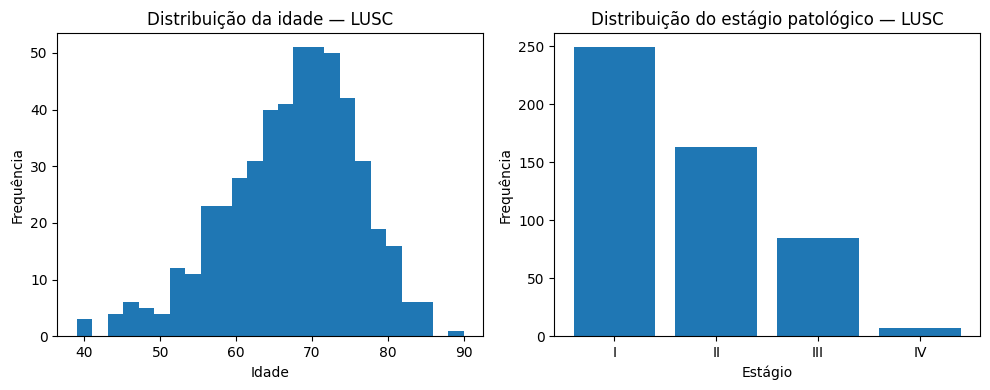

Figura salva: /workspaces/An-lise-de-Sobrevida/reports/figures/lusc/lusc_clinical_profile.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Idade
axes[0].hist(lusc_clin_sel["age_at_initial_pathologic_diagnosis"].dropna(), bins=25)
axes[0].set_title("Distribuição da idade — LUSC")
axes[0].set_xlabel("Idade")
axes[0].set_ylabel("Frequência")

# Estágio
ordem_estagios = ["I", "II", "III", "IV", "Unknown"]
stage_counts = lusc_clin_sel["pathologic_stage_group"].value_counts().reindex(ordem_estagios)

axes[1].bar(stage_counts.index.astype(str), stage_counts.values)
axes[1].set_title("Distribuição do estágio patológico — LUSC")
axes[1].set_xlabel("Estágio")
axes[1].set_ylabel("Frequência")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "lusc_clinical_profile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura salva:", FIGURES_DIR / "lusc_clinical_profile.png")

## 3. Tratamento da matriz de expressão gênica

A matriz de expressão gênica vem no formato genes x amostras.

Nesta etapa:
1. vou transpor a matriz;
2. criar `patient_id`;
3. manter apenas amostras tumorais primárias;
4. remover duplicatas por paciente.

In [36]:
print("LUSC — EXPRESSION")
print()

lusc_expr = pd.read_csv(FILES["expr"], sep="\t", index_col=0)

print("Tamanho genes x samples:", lusc_expr.shape)
print("Primeiros genes:", list(lusc_expr.index[:5]))
print("Primeiras amostras:", list(lusc_expr.columns[:5]))

LUSC — EXPRESSION

Tamanho genes x samples: (20530, 553)
Primeiros genes: ['ARHGEF10L', 'HIF3A', 'RNF17', 'RNF10', 'RNF11']
Primeiras amostras: ['TCGA-18-3417-01', 'TCGA-22-4613-01', 'TCGA-90-7769-01', 'TCGA-77-A5G1-01', 'TCGA-77-A5G3-01']


In [37]:
# Transpor para ficar amostras nas linhas e genes nas colunas
lusc_expr_t = (
    lusc_expr
    .T
    .reset_index()
    .rename(columns={"index": "sample"})
)

# Criar sample_code e patient_id
lusc_expr_t["sample_code"] = lusc_expr_t["sample"].apply(pegar_sample_code)
lusc_expr_t["patient_id"] = lusc_expr_t["sample"].apply(criar_patient_id)

print("Contagem sample_code na expressão:")
print(lusc_expr_t["sample_code"].value_counts(dropna=False).head())

display(lusc_expr_t[["sample", "sample_code", "patient_id"]].head())

Contagem sample_code na expressão:
sample_code
01    502
11     51
Name: count, dtype: int64


sample,sample,sample_code,patient_id
0,TCGA-18-3417-01,01,TCGA-18-3417
1,TCGA-22-4613-01,01,TCGA-22-4613
2,TCGA-90-7769-01,01,TCGA-90-7769
3,TCGA-77-A5G1-01,01,TCGA-77-A5G1
4,TCGA-77-A5G3-01,01,TCGA-77-A5G3


In [38]:
# Manter apenas amostras tumorais primárias
antes = len(lusc_expr_t)

lusc_expr_t = lusc_expr_t[lusc_expr_t["sample_code"] == "01"].copy()

depois_filtro = len(lusc_expr_t)

# Remover duplicatas por paciente
lusc_expr_t = (
    lusc_expr_t
    .sort_values("sample")
    .drop_duplicates(subset=["patient_id"], keep="first")
    .copy()
)

depois_dedup = len(lusc_expr_t)

print("Antes:", antes)
print("Após filtro sample_code == 01:", depois_filtro)
print("Após deduplicação:", depois_dedup)
print("Duplicatas removidas:", depois_filtro - depois_dedup)

Antes: 553
Após filtro sample_code == 01: 502
Após deduplicação: 502
Duplicatas removidas: 0


In [39]:
lusc_expr_final = lusc_expr_t.copy()

lusc_expr_final = lusc_expr_final.set_index("patient_id")

lusc_expr_final = lusc_expr_final.drop(
    columns=["sample", "sample_code"],
    errors="ignore"
)

# Garantir que os genes são numéricos
for col in lusc_expr_final.columns:
    lusc_expr_final[col] = pd.to_numeric(lusc_expr_final[col], errors="coerce")

mostrar_resumo(lusc_expr_final, "LUSC expression final")


LUSC expression final
------------------------------------------------------------
Shape: (502, 20530)
Total de nulos: 0


sample,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,C16orf13,C16orf11,FGFR1OP2,TSKS,ATRX,PMM2,LOC100272146,ASS1,NCBP1,ZNF709,ZNF708,RBM14,NCBP2,DISC1,CAMK1,RPL37,SPR,ZNF700,ZNF707,CAMK4,ZNF704,LOC339240,GOLGA6B,RNF115,RNF112,ZC3H14,SPN,HMGCLL1,NACAP1,LRRTM1,GRIN1,RBMY1A3P,DHX8,DHX9,LOC441204,TCOF1,LRRTM3,NUP98,XPC,SLC12A2,GRINA,LRRTM2,NUP93,HAP1,KLRA1,CAMKV,SPPL3,GOLIM4,ZNF646,OPA3,...,CAND1,PRPS1,CDR2,CDR1,RIMBP3,BRPF3,BRPF1,TTLL11,TTLL10,TTLL13,TTLL12,LDHD,GMPR2,AMELY,FOXD4,LDHB,LDHC,DNASE2B,ODF2L,FOXD2,ACAP1,ACAP2,ACAP3,LUZP4,OR10J5,LUZP6,C1orf198,CFL2,CFL1,OR10J3,C8orf83,C1orf192,PLAA,C8orf80,C8orf86,C8orf85,C8orf84,NFIC,NFIB,H1FOO,NFIX,PLEKHG6,PLEKHG7,PLEKHG4,PLEKHG5,SLC7A14,SELE,SLC7A10,PLA2G2C,METTL11A,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
patient_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
TCGA-18-3406,8.3772,4.3705,0.0000,11.4814,12.5148,12.5455,11.6055,4.0659,0.0000,3.5878,9.3085,0.0,10.0370,0.0000,10.4716,10.3731,5.6386,10.4914,9.8686,6.6241,7.8611,8.8393,11.3661,7.1193,8.3735,14.2462,10.1312,9.4662,5.7900,4.1956,6.4003,0.0000,2.5171,9.1595,4.9868,10.0207,7.2865,5.0222,8.1759,0.8379,0.0000,0.0000,9.4402,11.5160,4.1956,8.4698,0.0000,10.4400,7.8805,9.1753,11.1229,2.8677,9.6457,3.9964,4.5750,0.0000,10.6362,9.5804,7.1730,8.2374,...,12.2465,10.6023,8.6559,0.0000,3.0155,8.5508,6.5891,5.2180,0.0000,3.3366,10.5434,5.7271,11.3077,0.0,1.7494,12.2134,5.3352,3.2722,8.9319,5.7693,7.4707,11.8214,8.6217,4.7955,0.0,13.0361,10.1128,9.2556,13.6808,0.0000,11.0482,4.7113,7.4383,4.8751,0.0000,4.9133,6.3731,7.2496,9.4288,0.0000,9.8304,8.2524,5.4436,9.2122,9.0945,0.8379,8.5140,1.3776,0.0,9.5864,0.8379,1.3645,5.4173,6.8770,8.6783,10.8793,7.2645,10.5071,6.8770,10.8624
TCGA-18-3407,8.6982,4.1022,0.0000,11.4912,11.3877,11.1292,12.3323,3.3275,0.5614,4.2538,8.8709,0.0,8.6219,0.9646,10.4286,10.3900,5.0179,9.8041,10.1626,6.2420,7.1766,9.8832,11.7006,8.6263,7.0930,13.4394,9.5161,8.8709,7.5098,3.1839,7.6901,0.5614,1.7565,8.4303,4.0200,9.7801,6.6636,3.2575,6.6971,0.9646,4.0200,0.0000,10.9472,12.2486,2.7461,9.7871,0.0000,11.8592,8.9521,9.0577,12.0397,3.6343,10.3530,6.6704,4.5459,0.0000,10.7983,10.5458,8.8942,9.5928,...,11.2770,9.7675,8.9241,2.8449,3.4582,9.4685,8.6167,4.9749,1.5375,3.7176,11.4133,6.4836,10.0856,0.0,3.6886,12.4883,1.2793,0.0000,8.2526,4.5750,7.2048,11.9759,9.4394,0.0000,0.0,12.9883,10.8509,8.8413,14.0217,0.0000,8.9142,3.8872,10.4030,5.7240,0.5614,1.7565,9.2815,8.5920,9.9964,0.0000,10.4126,7.1382,4.0200,9.4132,9.3023,0.9646,8.1158,0.5614,0.0,8.9742,0.5614,0.0000,3.7408,2.9374,8.6306,12.4955,8.0396,10.7039,6.9061,10.5319
TCGA-18-3408,5.7494,5.2841,1.1286,11.4061,11.3861,13.3573,13.2288,3.0212,0.6719,0.6719,7.4691,0.0,9.7321,0.0000,10.2715,9.4846,3.7503,10.6987,10.3057,6.6869,7.4883,9.0318,11.1087,8.2086,7.9351,13.8233,10.4522,8.4938,5.6162,3.3072,7.0775,0.0000,1.4749,9.8397,2.3653,10.4006,7.1212,3.8126,7.7689,0.6719,1.1286,0.0000,10.3084,12.4642,3.0212,7.8379,0.0000,10.6220,9.0758,8.8663,11.3813,4.9931,10.2485,7.4883,5.3485,0.0000,11.0051,11.7029,6.8882,8.5813,...,11.9711,10.6595,8.3905,0.0000,5.5629,9.2177,7.2728,5.0968,1.1286,2.2832,9.9485,6.2431,11.0188,0.0,2.7933,12.7314,0.0000,3.0212,7.3535,2.9117,5.7334,11.5203,6.1131,0.6719,0.0,12.9659,9.7351,9.6923,13.9436,0.6719,9.4186,4.8520,10.2358,3.8722,0.0000,3.8722,9.2892,5.5809,11.1014,0.0000,9.0470,7.9073,4.4039,7.4496,5.1699,0.6719,3.9846,0.6719,0.0,7.8754,1.1286,0.0000,4.9101,3.4705,8.9517,11.5836,6.8141,10.7232,6.9587,10.6149
TCGA-18-3409,9.1811,5.4451,0.0000,11.4533,11.6602,11.1610,12.4251,4.5268,0.0000,4.5896,8.5343,0.0,9.2325,0.5972,10.8092,9.6342,5.5903,9.9053,9.6299,7.6175,7.1656,9.7736,11.2862,7.4457,8.6043,13.0567,9.5930,7.8144,7.1961,4.2440,8.2532,0.5972,0.5972,8.3651,3.4927,10.2653,8.1025,4.4271,7.4070,1.3440,1.0183,0.0000,10.1312,12.0027,5.6357,9.4299,1.0183,10.9665,9.5571,9.1913,12.2622,4.2044,10.0001,4.8681,4.5268,0.5972,10.6540,10.6383,9.1186,8.2163,..

In [41]:
lusc_expr_final.reset_index().to_csv(
    PROCESSED_DIR / "lusc_expression_clean.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print("Arquivo salvo:", PROCESSED_DIR / "lusc_expression_clean.csv")

Arquivo salvo: /workspaces/An-lise-de-Sobrevida/data/processed/lusc/lusc_expression_clean.csv


## 4. Integração das bases

Agora vou integrar:

- base de sobrevida;
- base clínica;
- matriz de expressão gênica.

A integração será feita por `patient_id`, mantendo apenas pacientes presentes nas três bases.

In [42]:
surv_ids = set(lusc_surv_final.index.astype(str))
clin_ids = set(lusc_clin_final.index.astype(str))
expr_ids = set(lusc_expr_final.index.astype(str))

resumo_overlap = pd.DataFrame({
    "base": [
        "survival",
        "clinical",
        "expression",
        "survival ∩ clinical",
        "survival ∩ expression",
        "clinical ∩ expression",
        "survival ∩ clinical ∩ expression"
    ],
    "n_pacientes": [
        len(surv_ids),
        len(clin_ids),
        len(expr_ids),
        len(surv_ids & clin_ids),
        len(surv_ids & expr_ids),
        len(clin_ids & expr_ids),
        len(surv_ids & clin_ids & expr_ids)
    ]
})

display(resumo_overlap)

resumo_overlap.to_csv(
    PROCESSED_DIR / "lusc_overlap_summary.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

,base,n_pacientes
0,survival,497
1,clinical,504
2,expression,502
3,survival ∩ clinical,497
4,survival ∩ expression,494
5,clinical ∩ expression,501
6,survival ∩ clinical ∩ expression,494


In [43]:
surv = lusc_surv_final.copy()
clin = lusc_clin_final.copy()
expr = lusc_expr_final.copy()

# Garantir índice como texto
surv.index = surv.index.astype(str)
clin.index = clin.index.astype(str)
expr.index = expr.index.astype(str)

# Remover duplicados no índice, se existir
surv = surv[~surv.index.duplicated(keep="first")]
clin = clin[~clin.index.duplicated(keep="first")]
expr = expr[~expr.index.duplicated(keep="first")]

# Fazer join interno
df_lusc_final = pd.concat(
    [
        surv.add_prefix("surv__"),
        clin.add_prefix("clin__"),
        expr
    ],
    axis=1,
    join="inner"
)

mostrar_resumo(df_lusc_final, "Base integrada LUSC")


Base integrada LUSC
------------------------------------------------------------
Shape: (494, 20575)
Total de nulos: 69


,surv__OS.time,surv__OS,clin__age_at_initial_pathologic_diagnosis,clin__number_pack_years_smoked,clin__tobacco_smoking_history,clin__age_at_initial_pathologic_diagnosis_missing,clin__number_pack_years_smoked_missing,clin__tobacco_smoking_history_missing,clin__gender_bin,clin__history_of_neoadjuvant_treatment_bin,clin__radiation_therapy_bin,clin__anatomic_neoplasm_subdivision_Bronchial,clin__anatomic_neoplasm_subdivision_L-Lower,clin__anatomic_neoplasm_subdivision_L-Upper,clin__anatomic_neoplasm_subdivision_Other (please specify),clin__anatomic_neoplasm_subdivision_R-Lower,clin__anatomic_neoplasm_subdivision_R-Middle,clin__anatomic_neoplasm_subdivision_R-Upper,clin__anatomic_neoplasm_subdivision_Unknown,clin__anatomic_neoplasm_subdivision_[Discrepancy],clin__histological_type_Lung Basaloid Squamous Cell Carcinoma,clin__histological_type_Lung Papillary Squamous Cell Caricnoma,clin__histological_type_Lung Small Cell Squamous Cell Carcinoma,clin__histological_type_Lung Squamous Cell Carcinoma- Not Otherwise Specified (NOS),clin__pathologic_stage_group_I,clin__pathologic_stage_group_II,clin__pathologic_stage_group_III,clin__pathologic_stage_group_IV,clin__pathologic_T_group_T1,clin__pathologic_T_group_T2,clin__pathologic_T_group_T3,clin__pathologic_T_group_T4,clin__pathologic_N_group_N0,clin__pathologic_N_group_N1,clin__pathologic_N_group_N2,clin__pathologic_N_group_N3,clin__pathologic_N_group_NX,clin__pathologic_M_group_M0,clin__pathologic_M_group_M1,clin__pathologic_M_group_MX,clin__residual_tumor_R0,clin__residual_tumor_R1,clin__residual_tumor_R2,clin__residual_tumor_RX,clin__residual_tumor_Unknown,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,C16orf13,C16orf11,FGFR1OP2,TSKS,ATRX,...,CAND1,PRPS1,CDR2,CDR1,RIMBP3,BRPF3,BRPF1,TTLL11,TTLL10,TTLL13,TTLL12,LDHD,GMPR2,AMELY,FOXD4,LDHB,LDHC,DNASE2B,ODF2L,FOXD2,ACAP1,ACAP2,ACAP3,LUZP4,OR10J5,LUZP6,C1orf198,CFL2,CFL1,OR10J3,C8orf83,C1orf192,PLAA,C8orf80,C8orf86,C8orf85,C8orf84,NFIC,NFIB,H1FOO,NFIX,PLEKHG6,PLEKHG7,PLEKHG4,PLEKHG5,SLC7A14,SELE,SLC7A10,PLA2G2C,METTL11A,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
patient_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
TCGA-18-3406,371.0,1,67.0,200.0,4.0,0,0,0,1,0.0,0.0,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,8.3772,4.3705,0.0000,11.4814,12.5148,12.5455,11.6055,4.0659,0.0000,3.5878,9.3085,0.0,10.0370,0.0000,10.4716,...,12.2465,10.6023,8.6559,0.0000,3.0155,8.5508,6.5891,5.2180,0.0000,3.3366,10.5434,5.7271,11.3077,0.0,1.7494,12.2134,5.3352,3.2722,8.9319,5.7693,7.4707,11.8214,8.6217,4.7955,0.0,13.0361,10.1128,9.2556,13.6808,0.0000,11.0482,4.7113,7.4383,4.8751,0.0000,4.9133,6.3731,7.2496,9.4288,0.0000,9.8304,8.2524,5.4436,9.2122,9.0945,0.8379,8.5140,1.3776,0.0,9.5864,0.8379,1.3645,5.4173,6.8770,8.6783,10.8793,7.2645,10.5071,6.8770,10.8624
TCGA-18-3407,136.0,1,72.0,40.0,3.0,0,0,0,1,0.0,0.0,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,8.6982,4.1022,0.0000,11.4912,11.3877,11.1292,12.3323,3.3275,0.5614,4.2538,8.8709,0.0,8.6219,0.9646,10.4286,...,11.2770,9.7675,8.9241,2.8449,3.4582,9.4685,8.6167,4.9749,1.5375,3.7176,11.4133,6.4836,10.0856,0.0,3.6886,12.4883,1.2793,0.0000,8.2526,4.5750,7.2048,11.9759,9.4394,0.0000,0.0,12.9883,10.8509,8.8413,14.0217,0.0000,8.9142,3.8872,10.4030,5.7240,0.5614,1.7565,9.2815,8.5920,9.9964,0.0000,10.4126,7.1382,4.0200,9.4132,9.3023,0.9646,8.1158,0.5614,0.0,8.9742,0.5614,0.0000,3.7408,2.9374,8.6306,12.4955,8.0396,10.7039,6.9061,10.5319
TCGA-18-3408,2304.0,1,77.0,30.0,4.0,0,0,0,0,0.0,0.0,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,True,Fa

In [44]:
df_lusc_final.reset_index(names="patient_id").to_csv(
    PROCESSED_DIR / "lusc_integrated_full.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print("Arquivo salvo:", PROCESSED_DIR / "lusc_integrated_full.csv")

Arquivo salvo: /workspaces/An-lise-de-Sobrevida/data/processed/lusc/lusc_integrated_full.csv


## 5. Genes selecionados da literatura

Nesta etapa, vou criar a lista de genes relacionados ao LUSC e NSCLC descritos na literatura.

Depois vou verificar quais genes estão presentes na matriz de expressão.

In [45]:
# Assinatura imune 10 genes
genes_lusc_10 = [
    "CALCB", "GCGR", "HTR3A", "AMH", "VGF",
    "SEMA3B", "NRTN", "ENG", "ACVRL1", "NR4A1"
]

# Assinatura imune 13 genes
genes_lusc_13 = [
    "FGF4", "FGL1", "LIM2", "NPY", "F13A1",
    "CDH12", "CD1E", "OTX2", "ADRA1D",
    "SAMD9L", "ZFP42", "GAGE2A", "KLRC2"
]

# Assinatura glicolítica 3 genes
genes_lusc_glicolise = [
    "HKDC1", "ALDH7A1", "MDH1"
]

# Assinatura prognóstica NSCLC
genes_nsclc = [
    "ABCC4", "CCL19", "SLC39A8", "CD27",
    "FUT7", "DAG1", "ZNF71"
]

# Drivers clássicos de LUSC
genes_lusc_drivers = [
    "TP53", "CDKN2A", "PTEN", "PIK3CA", "KEAP1",
    "NFE2L2", "NOTCH1", "RB1", "SOX2", "TP63", "FGFR1"
]

genes_literatura = (
    genes_lusc_10
    + genes_lusc_13
    + genes_lusc_glicolise
    + genes_nsclc
    + genes_lusc_drivers
)

# Remover duplicados mantendo a ordem
genes_literatura = list(dict.fromkeys(genes_literatura))

print("Total genes literatura:", len(genes_literatura))
print(genes_literatura)

Total genes literatura: 44
['CALCB', 'GCGR', 'HTR3A', 'AMH', 'VGF', 'SEMA3B', 'NRTN', 'ENG', 'ACVRL1', 'NR4A1', 'FGF4', 'FGL1', 'LIM2', 'NPY', 'F13A1', 'CDH12', 'CD1E', 'OTX2', 'ADRA1D', 'SAMD9L', 'ZFP42', 'GAGE2A', 'KLRC2', 'HKDC1', 'ALDH7A1', 'MDH1', 'ABCC4', 'CCL19', 'SLC39A8', 'CD27', 'FUT7', 'DAG1', 'ZNF71', 'TP53', 'CDKN2A', 'PTEN', 'PIK3CA', 'KEAP1', 'NFE2L2', 'NOTCH1', 'RB1', 'SOX2', 'TP63', 'FGFR1']


In [46]:
genes_presentes = [g for g in genes_literatura if g in df_lusc_final.columns]
genes_ausentes = [g for g in genes_literatura if g not in df_lusc_final.columns]

print("Genes presentes:", len(genes_presentes))
print(genes_presentes)

print("\nGenes ausentes:", len(genes_ausentes))
print(genes_ausentes)

tabela_genes_disponibilidade = pd.DataFrame({
    "gene": genes_literatura,
    "presente_na_base": [g in genes_presentes for g in genes_literatura]
})

display(tabela_genes_disponibilidade)

tabela_genes_disponibilidade.to_csv(
    PROCESSED_DIR / "lusc_gene_availability.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

Genes presentes: 44
['CALCB', 'GCGR', 'HTR3A', 'AMH', 'VGF', 'SEMA3B', 'NRTN', 'ENG', 'ACVRL1', 'NR4A1', 'FGF4', 'FGL1', 'LIM2', 'NPY', 'F13A1', 'CDH12', 'CD1E', 'OTX2', 'ADRA1D', 'SAMD9L', 'ZFP42', 'GAGE2A', 'KLRC2', 'HKDC1', 'ALDH7A1', 'MDH1', 'ABCC4', 'CCL19', 'SLC39A8', 'CD27', 'FUT7', 'DAG1', 'ZNF71', 'TP53', 'CDKN2A', 'PTEN', 'PIK3CA', 'KEAP1', 'NFE2L2', 'NOTCH1', 'RB1', 'SOX2', 'TP63', 'FGFR1']

Genes ausentes: 0
[]


,gene,presente_na_base
0,CALCB,True
1,GCGR,True
2,HTR3A,True
3,AMH,True
4,VGF,True
5,SEMA3B,True
6,NRTN,True
7,ENG,True
8,ACVRL1,True
9,NR4A1,True


## 6. Análise de Cox univariada por gene

Agora vou testar cada gene da literatura separadamente com Cox univariado.

O objetivo é verificar quais genes possuem associação com a sobrevida na base LUSC.

Serão calculados:
- coeficiente;
- HR;
- erro padrão;
- z;
- p-valor;
- intervalo de confiança;
- q-valor com FDR.

Observação importante:
essa etapa deve ser descrita como exploratória, porque se os genes selecionados por p-valor forem usados depois nos modelos, existe risco de vazamento de informação.

In [47]:
def rodar_cox_univariado(df, genes, time_col, event_col):
    rows = []

    for gene in genes:
        tmp = df[[time_col, event_col, gene]].copy()

        tmp[time_col] = pd.to_numeric(tmp[time_col], errors="coerce")
        tmp[event_col] = pd.to_numeric(tmp[event_col], errors="coerce")
        tmp[gene] = pd.to_numeric(tmp[gene], errors="coerce")

        tmp = tmp.dropna()

        status = "ok"

        if tmp.shape[0] < 20:
            status = "n_insuficiente"
        elif tmp[gene].nunique() < 2:
            status = "sem_variacao_gene"
        elif tmp[event_col].nunique() < 2:
            status = "sem_variacao_evento"
        elif tmp[gene].std() == 0:
            status = "desvio_zero"

        if status != "ok":
            rows.append({
                "gene": gene,
                "n": len(tmp),
                "coef": np.nan,
                "HR": np.nan,
                "se": np.nan,
                "z": np.nan,
                "p": np.nan,
                "ci95_inf": np.nan,
                "ci95_sup": np.nan,
                "status": status
            })
            continue

        # Padronizar gene para comparar HR por 1 desvio-padrão
        tmp[gene] = (tmp[gene] - tmp[gene].mean()) / tmp[gene].std()

        try:
            cph = CoxPHFitter()
            cph.fit(
                tmp,
                duration_col=time_col,
                event_col=event_col
            )

            s = cph.summary.loc[gene]

            rows.append({
                "gene": gene,
                "n": len(tmp),
                "coef": s["coef"],
                "HR": s["exp(coef)"],
                "se": s["se(coef)"],
                "z": s["z"],
                "p": s["p"],
                "ci95_inf": s["exp(coef) lower 95%"],
                "ci95_sup": s["exp(coef) upper 95%"],
                "status": "ok"
            })

        except Exception as e:
            rows.append({
                "gene": gene,
                "n": len(tmp),
                "coef": np.nan,
                "HR": np.nan,
                "se": np.nan,
                "z": np.nan,
                "p": np.nan,
                "ci95_inf": np.nan,
                "ci95_sup": np.nan,
                "status": f"erro: {str(e)}"
            })

    resultado = pd.DataFrame(rows)

    # Correção de múltiplos testes
    resultado["q_value"] = np.nan
    mask = resultado["p"].notna()

    if mask.sum() > 0:
        resultado.loc[mask, "q_value"] = multipletests(
            resultado.loc[mask, "p"],
            method="fdr_bh"
        )[1]

    # Classificar efeito
    resultado["efeito"] = np.where(
        resultado["HR"] > 1,
        "alto_risco",
        np.where(resultado["HR"] < 1, "protetor", "neutro")
    )

    resultado = resultado.sort_values("p", na_position="last").reset_index(drop=True)

    return resultado

In [48]:
time_col = "surv__OS.time"
event_col = "surv__OS"

res_cox_lusc = rodar_cox_univariado(
    df=df_lusc_final,
    genes=genes_presentes,
    time_col=time_col,
    event_col=event_col
)

display(res_cox_lusc)

,gene,n,coef,HR,se,z,p,ci95_inf,ci95_sup,status,q_value,efeito
0,ZFP42,494,0.233679,1.263239,0.065668,3.558517,0.000373,1.110681,1.436753,ok,0.016410,alto_risco
1,ALDH7A1,494,0.231919,1.261018,0.070238,3.301887,0.000960,1.098839,1.447132,ok,0.021128,alto_risco
2,HKDC1,494,0.216835,1.242140,0.069197,3.133608,0.001727,1.084601,1.422561,ok,0.025325,alto_risco
3,NRTN,494,-0.196298,0.821767,0.068495,-2.865889,0.004158,0.718532,0.939835,ok,0.042976,protetor
4,OTX2,494,-0.214221,0.807170,0.076111,-2.814609,0.004884,0.695312,0.937023,ok,0.042976,protetor
5,GCGR,494,-0.211900,0.809046,0.078545,-2.697818,0.006980,0.693610,0.943693,ok,0.051183,protetor
6,F13A1,494,0.184076,1.202107,0.069941,2.631873,0.008492,1.048116,1.378723,ok,0.053376,alto_risco
7,ACVRL1,494,0.173695,1.189693,0.069666,2.493261,0.012658,1.037851,1.363750,ok,0.069617,alto_risco
8,MDH1,494,-0.182412,0.833258,0.075053,-2.430430,0.015081,0.719273,0.965306,ok,0.073729,protetor
9,SEMA3B,494,0.151438,1.163507,0.064182,2.359514,0.018299,1.025976,1.319474,ok,0.080515,alto_risco


In [49]:
top_p = res_cox_lusc[
    (res_cox_lusc["status"] == "ok")
    & (res_cox_lusc["p"] < 0.05)
].copy()

print("Genes com p < 0.05:", len(top_p))

display(
    top_p[["gene", "HR", "ci95_inf", "ci95_sup", "p", "q_value", "efeito", "n"]]
)

Genes com p < 0.05: 15


,gene,HR,ci95_inf,ci95_sup,p,q_value,efeito,n
0,ZFP42,1.263239,1.110681,1.436753,0.000373,0.016410,alto_risco,494
1,ALDH7A1,1.261018,1.098839,1.447132,0.000960,0.021128,alto_risco,494
2,HKDC1,1.242140,1.084601,1.422561,0.001727,0.025325,alto_risco,494
3,NRTN,0.821767,0.718532,0.939835,0.004158,0.042976,protetor,494
4,OTX2,0.807170,0.695312,0.937023,0.004884,0.042976,protetor,494
5,GCGR,0.809046,0.693610,0.943693,0.006980,0.051183,protetor,494
6,F13A1,1.202107,1.048116,1.378723,0.008492,0.053376,alto_risco,494
7,ACVRL1,1.189693,1.037851,1.363750,0.012658,0.069617,alto_risco,494
8,MDH1,0.833258,0.719273,0.965306,0.015081,0.073729,protetor,494
9,SEMA3B,1.163507,1.025976,1.319474,0.018299,0.080515,alto_risco,494


In [50]:
genes_top_p = top_p["gene"].tolist()

print("genes_top_p =")
print(genes_top_p)

genes_top_p =
['ZFP42', 'ALDH7A1', 'HKDC1', 'NRTN', 'OTX2', 'GCGR', 'F13A1', 'ACVRL1', 'MDH1', 'SEMA3B', 'ZNF71', 'FGF4', 'GAGE2A', 'SLC39A8', 'SOX2']


In [51]:
res_cox_lusc.to_csv(
    PROCESSED_DIR / "lusc_cox_univariate_genes.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print("Arquivo salvo:", PROCESSED_DIR / "lusc_cox_univariate_genes.csv")

Arquivo salvo: /workspaces/An-lise-de-Sobrevida/data/processed/lusc/lusc_cox_univariate_genes.csv


## 7. Base final para modelagem

Agora vou montar a base que será usada nos modelos de sobrevida.

A base final terá:
- colunas de sobrevida;
- variáveis clínicas tratadas;
- genes selecionados por Cox univariado exploratório.

Importante:
`vital_status` não entra como preditora.

In [52]:
# Escolha dos genes finais
genes_escolhidos = genes_top_p.copy()

# Colunas de sobrevida
surv_cols = [c for c in df_lusc_final.columns if c.startswith("surv__")]

# Colunas clínicas
clin_cols = [c for c in df_lusc_final.columns if c.startswith("clin__")]

# Garantia extra: remover qualquer coluna com vital_status
clin_cols = [
    c for c in clin_cols
    if "vital_status" not in c.lower()
]

# Genes presentes no dataframe
genes_presentes_modelo = [g for g in genes_escolhidos if g in df_lusc_final.columns]
genes_ausentes_modelo = [g for g in genes_escolhidos if g not in df_lusc_final.columns]

print("Colunas survival:", len(surv_cols))
print("Colunas clínicas:", len(clin_cols))
print("Genes presentes:", genes_presentes_modelo)
print("Genes ausentes:", genes_ausentes_modelo)

cols_finais = surv_cols + clin_cols + genes_presentes_modelo
cols_finais = list(dict.fromkeys(cols_finais))

df_lusc_modelo = df_lusc_final[cols_finais].copy()

print("Shape final:", df_lusc_modelo.shape)

display(df_lusc_modelo.head())

Colunas survival: 2
Colunas clínicas: 43
Genes presentes: ['ZFP42', 'ALDH7A1', 'HKDC1', 'NRTN', 'OTX2', 'GCGR', 'F13A1', 'ACVRL1', 'MDH1', 'SEMA3B', 'ZNF71', 'FGF4', 'GAGE2A', 'SLC39A8', 'SOX2']
Genes ausentes: []
Shape final: (494, 60)


,surv__OS.time,surv__OS,clin__age_at_initial_pathologic_diagnosis,clin__number_pack_years_smoked,clin__tobacco_smoking_history,clin__age_at_initial_pathologic_diagnosis_missing,clin__number_pack_years_smoked_missing,clin__tobacco_smoking_history_missing,clin__gender_bin,clin__history_of_neoadjuvant_treatment_bin,clin__radiation_therapy_bin,clin__anatomic_neoplasm_subdivision_Bronchial,clin__anatomic_neoplasm_subdivision_L-Lower,clin__anatomic_neoplasm_subdivision_L-Upper,clin__anatomic_neoplasm_subdivision_Other (please specify),clin__anatomic_neoplasm_subdivision_R-Lower,clin__anatomic_neoplasm_subdivision_R-Middle,clin__anatomic_neoplasm_subdivision_R-Upper,clin__anatomic_neoplasm_subdivision_Unknown,clin__anatomic_neoplasm_subdivision_[Discrepancy],clin__histological_type_Lung Basaloid Squamous Cell Carcinoma,clin__histological_type_Lung Papillary Squamous Cell Caricnoma,clin__histological_type_Lung Small Cell Squamous Cell Carcinoma,clin__histological_type_Lung Squamous Cell Carcinoma- Not Otherwise Specified (NOS),clin__pathologic_stage_group_I,clin__pathologic_stage_group_II,clin__pathologic_stage_group_III,clin__pathologic_stage_group_IV,clin__pathologic_T_group_T1,clin__pathologic_T_group_T2,clin__pathologic_T_group_T3,clin__pathologic_T_group_T4,clin__pathologic_N_group_N0,clin__pathologic_N_group_N1,clin__pathologic_N_group_N2,clin__pathologic_N_group_N3,clin__pathologic_N_group_NX,clin__pathologic_M_group_M0,clin__pathologic_M_group_M1,clin__pathologic_M_group_MX,clin__residual_tumor_R0,clin__residual_tumor_R1,clin__residual_tumor_R2,clin__residual_tumor_RX,clin__residual_tumor_Unknown,ZFP42,ALDH7A1,HKDC1,NRTN,OTX2,GCGR,F13A1,ACVRL1,MDH1,SEMA3B,ZNF71,FGF4,GAGE2A,SLC39A8,SOX2
patient_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
TCGA-18-3406,371.0,1,67.0,200.0,4.0,0,0,0,1,0.0,0.0,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,1.7494,8.6559,5.2778,2.8677,1.3645,4.0659,10.0489,9.0286,13.0819,4.7113,8.0951,0.0000,0.0000,10.4514,8.4698
TCGA-18-3407,136.0,1,72.0,40.0,3.0,0,0,0,1,0.0,0.0,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,0.0000,7.8593,6.1676,2.7461,0.9646,3.5193,8.2571,8.9985,12.0345,6.8297,5.6575,0.0000,3.9771,10.3928,12.2245
TCGA-18-3408,2304.0,1,77.0,30.0,4.0,0,0,0,0,0.0,0.0,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,0.0000,7.7650,5.0458,0.6719,1.4749,0.0000,11.7268,8.2709,12.4069,3.6172,5.5986,0.6719,0.0000,10.1578,13.3835
TCGA-18-3409,3747.0,0,74.0,20.0,3.0,0,0,0,1,0.0,0.0,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,1.3440,10.7186,3.4254,9.0350,1.8335,2.7314,10.7797,9.7230,11.6099,10.1626,7.9463,0.0000,0.0000,9.7864,5.2450
TCGA-18-3410,146.0,1,81.0,0.0,3.0,0,1,0,1,0.0,0.0,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,True,False,False,False,False,True,False,False,True,False,False,False,False,0.4791,10.3908,4.9875,3.6349,3.5404,1.1255,8.6900,10.2864,11.8564,4.2569,8.5270,0.0000,0.0000,9.5320,9.3927


In [53]:
nulos_modelo = (
    df_lusc_modelo
    .isna()
    .sum()
    .sort_values(ascending=False)
)

nulos_modelo = nulos_modelo[nulos_modelo > 0]

print("Colunas com nulos na base final:")

display(nulos_modelo)

Colunas com nulos na base final:


clin__radiation_therapy_bin                   68
clin__history_of_neoadjuvant_treatment_bin     1
dtype: int64

In [54]:
# Tratamento simples para evitar perda grande de pacientes no notebook de modelos
for col in df_lusc_modelo.columns:
    if col in surv_cols:
        continue

    if df_lusc_modelo[col].isna().sum() > 0:
        mediana = df_lusc_modelo[col].median()
        df_lusc_modelo[col] = df_lusc_modelo[col].fillna(mediana)

print("Total de nulos após tratamento:", int(df_lusc_modelo.isna().sum().sum()))

Total de nulos após tratamento: 0


In [55]:
resumo_modelo_lusc = pd.DataFrame({
    "coorte": ["LUSC"],
    "n_pacientes": [df_lusc_modelo.shape[0]],
    "n_colunas_total": [df_lusc_modelo.shape[1]],
    "n_colunas_sobrevida": [len(surv_cols)],
    "n_colunas_clinicas": [len(clin_cols)],
    "n_genes": [len(genes_presentes_modelo)],
    "taxa_eventos_%": [round(df_lusc_modelo["surv__OS"].mean() * 100, 2)]
})

display(resumo_modelo_lusc)

resumo_modelo_lusc.to_csv(
    PROCESSED_DIR / "lusc_modeling_dataset_summary.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

,coorte,n_pacientes,n_colunas_total,n_colunas_sobrevida,n_colunas_clinicas,n_genes,taxa_eventos_%
0,LUSC,494,60,2,43,15,42.91


In [56]:
df_lusc_modelo.reset_index(names="patient_id").to_csv(
    PROCESSED_DIR / "lusc_modeling_dataset.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print("Arquivo salvo:", PROCESSED_DIR / "lusc_modeling_dataset.csv")

Arquivo salvo: /workspaces/An-lise-de-Sobrevida/data/processed/lusc/lusc_modeling_dataset.csv


In [57]:
print("CHECKLIST FINAL — LUSC")
print("-" * 60)

print("Survival:", lusc_surv_final.shape)
print("Clinical:", lusc_clin_final.shape)
print("Expression:", lusc_expr_final.shape)
print("Integrated full:", df_lusc_final.shape)
print("Modeling dataset:", df_lusc_modelo.shape)

print("\nArquivos gerados:")
for arquivo in sorted(PROCESSED_DIR.glob("*.csv")):
    print("-", arquivo.name)

print("\nFiguras geradas:")
for figura in sorted(FIGURES_DIR.glob("*.png")):
    print("-", figura.name)

CHECKLIST FINAL — LUSC
------------------------------------------------------------
Survival: (497, 2)
Clinical: (504, 43)
Expression: (502, 20530)
Integrated full: (494, 20575)
Modeling dataset: (494, 60)

Arquivos gerados:
- lusc_clinical_clean.csv
- lusc_cox_univariate_genes.csv
- lusc_expression_clean.csv
- lusc_gene_availability.csv
- lusc_integrated_full.csv
- lusc_modeling_dataset.csv
- lusc_modeling_dataset_summary.csv
- lusc_overlap_summary.csv
- lusc_survival_clean.csv
- lusc_survival_summary.csv

Figuras geradas:
- lusc_clinical_profile.png
- lusc_kaplan_meier.png
